In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# Database connection
connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="Aditya@123",
    host="localhost",
    port=3306,
    database="retail_forecasting"
)

engine = create_engine(connection_url)

# Load data
df = pd.read_sql("SELECT * FROM retail_sales", engine)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Display first rows
df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Weather_Condition,Promotion,Competitor_Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   Date                76000 non-null  datetime64[s]
 1   Store_ID            76000 non-null  str          
 2   Product_ID          76000 non-null  str          
 3   Category            76000 non-null  str          
 4   Region              76000 non-null  str          
 5   Inventory_Level     76000 non-null  int64        
 6   Units_Sold          76000 non-null  int64        
 7   Units_Ordered       76000 non-null  int64        
 8   Price               76000 non-null  float64      
 9   Discount            76000 non-null  int64        
 10  Weather_Condition   76000 non-null  str          
 11  Promotion           76000 non-null  int64        
 12  Competitor_Pricing  76000 non-null  float64      
 13  Seasonality         76000 non-null  str          
 14  Epidemic         

In [6]:
df.describe()

,Date,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Promotion,Competitor_Pricing,Epidemic,Demand
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801


In [8]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              0
Weather_Condition     0
Promotion             0
Competitor_Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

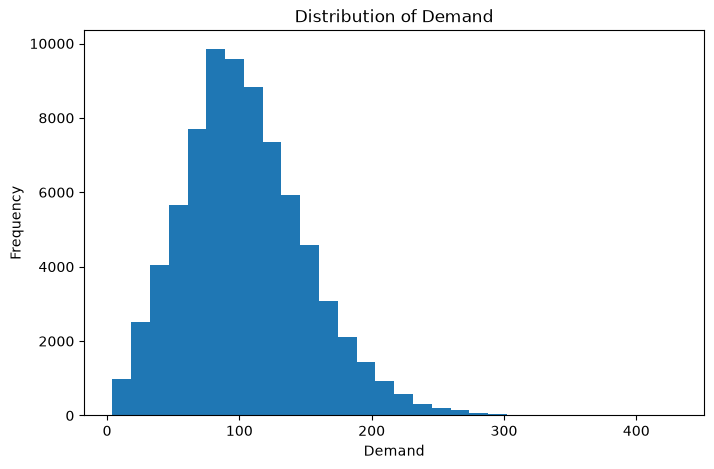

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Demand"], bins=30)
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

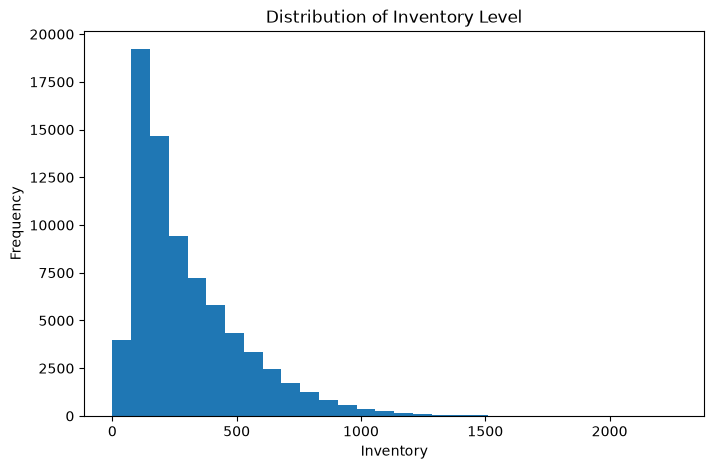

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["Inventory_Level"], bins=30)
plt.title("Distribution of Inventory Level")
plt.xlabel("Inventory")
plt.ylabel("Frequency")
plt.show()

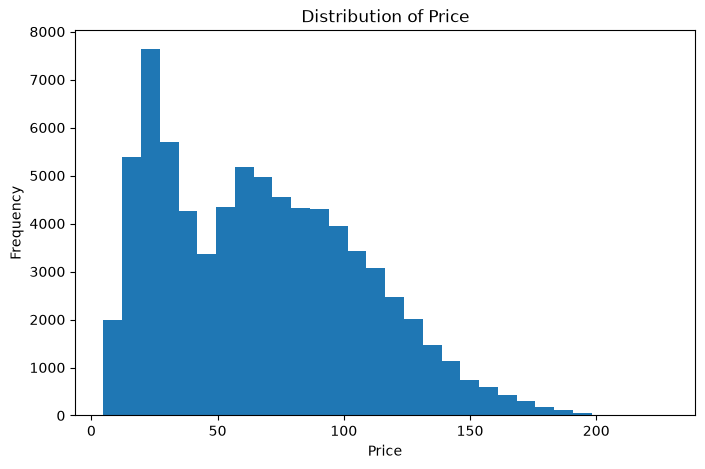

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

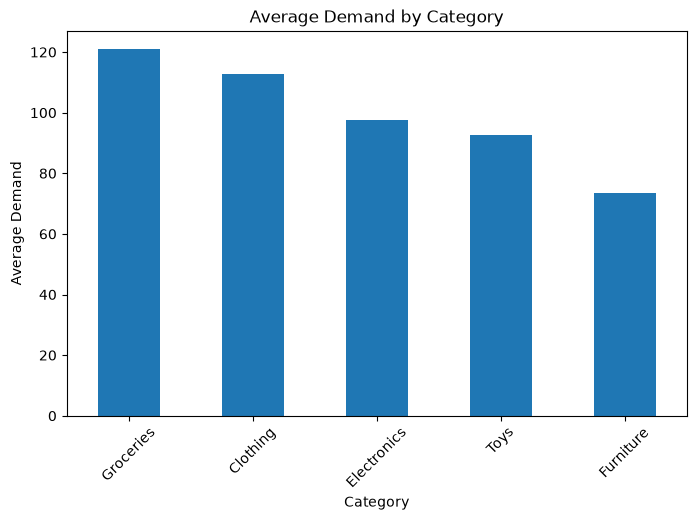

In [12]:
category_demand = df.groupby("Category")["Demand"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_demand.plot(kind="bar")
plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

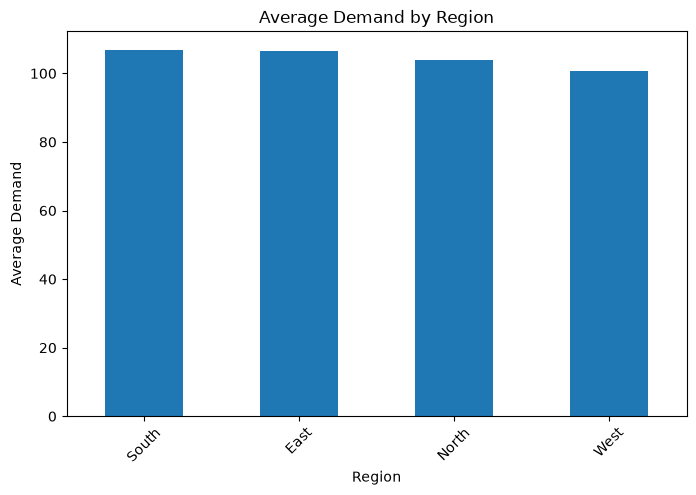

In [13]:
region_demand = df.groupby("Region")["Demand"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_demand.plot(kind="bar")
plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

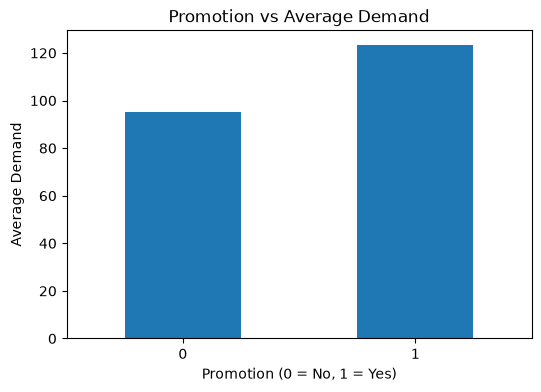

In [14]:
promotion_demand = df.groupby("Promotion")["Demand"].mean()

plt.figure(figsize=(6,4))
promotion_demand.plot(kind="bar")
plt.title("Promotion vs Average Demand")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Demand")
plt.xticks(rotation=0)
plt.show()

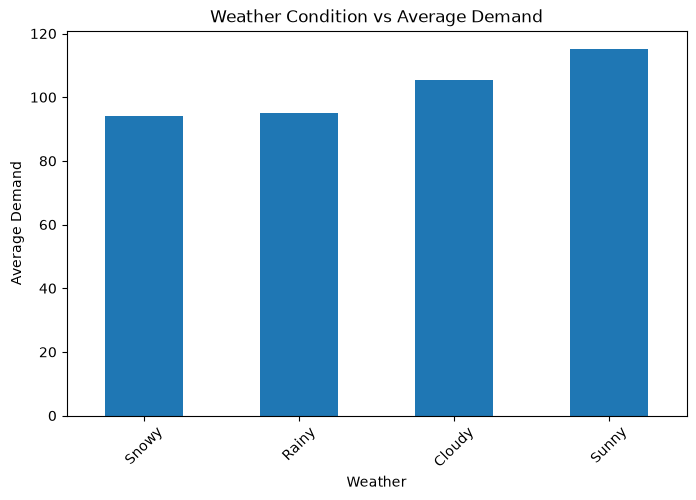

In [15]:
weather_demand = df.groupby("Weather_Condition")["Demand"].mean().sort_values()

plt.figure(figsize=(8,5))
weather_demand.plot(kind="bar")
plt.title("Weather Condition vs Average Demand")
plt.xlabel("Weather")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

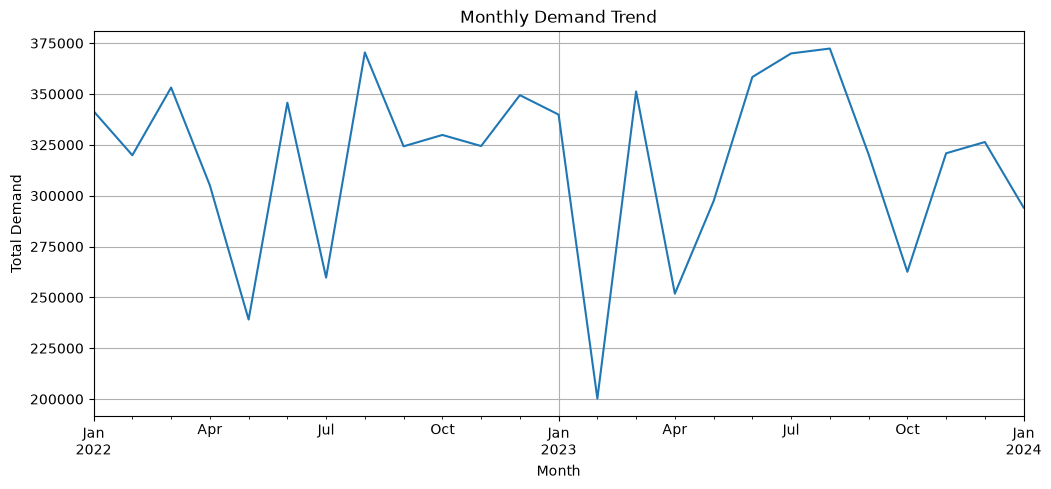

In [16]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_demand = df.groupby("Month")["Demand"].sum()

plt.figure(figsize=(12,5))
monthly_demand.plot()
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.grid(True)
plt.show()

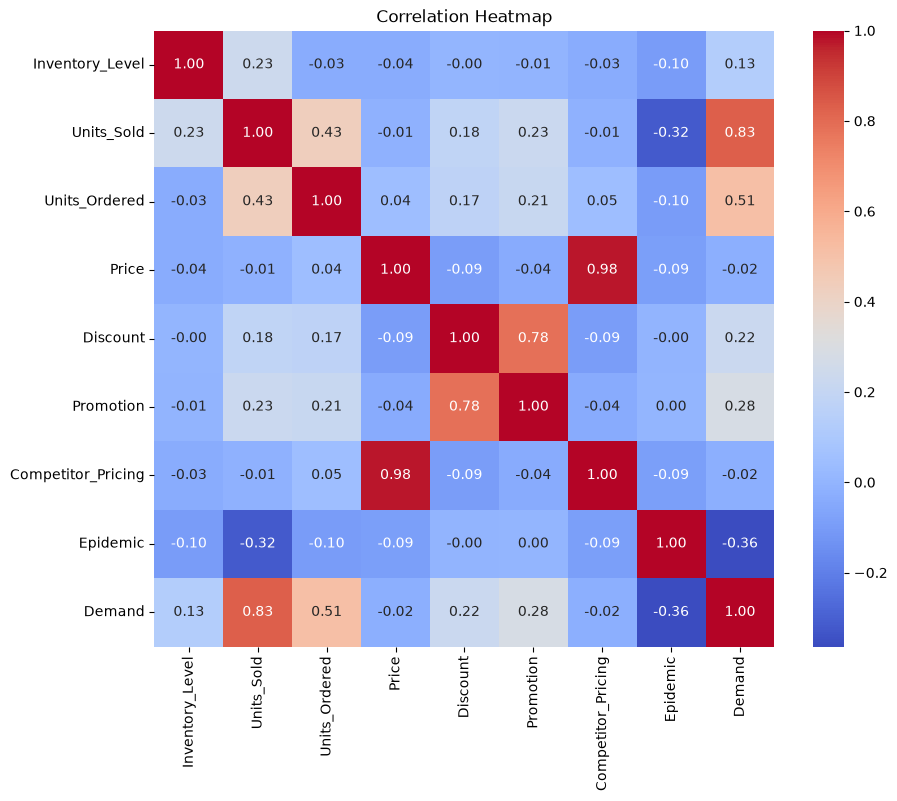

In [17]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()